In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
df=pd.read_csv("Employee_Data.csv")

In [111]:
df.head()

,Unnamed: 0,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work,Department,Region
0,0,EMP1000,Bob,Davis,25,DevOps-California,Active,2021-04-02,59767.65,bob.davis@example.com,1651623197,Average,True,DevOps,California
1,1,EMP1001,Bob,Brown,30,Finance-Texas,Active,2020-07-10,65304.66,bob.brown@example.com,1898471390,Excellent,True,Finance,Texas
2,2,EMP1002,Alice,Jones,30,Admin-Nevada,Pending,2023-12-07,88145.90,alice.jones@example.com,5596363211,Good,True,Admin,Nevada
3,3,EMP1003,Eva,Davis,25,Admin-Nevada,Inactive,2021-11-27,69450.99,eva.davis@example.com,3476490784,Good,True,Admin,Nevada
4,4,EMP1004,Frank,Williams,25,Cloud Tech-Florida,Active,2022-01-05,109324.61,frank.williams@example.com,1586734256,Poor,False,Cloud Tech,Florida


C:\Users\amank\AppData\Local\Temp\ipykernel_26424\3736397343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  dept_chart=sns.countplot(x= 'Department' , data=df, palette='viridis')


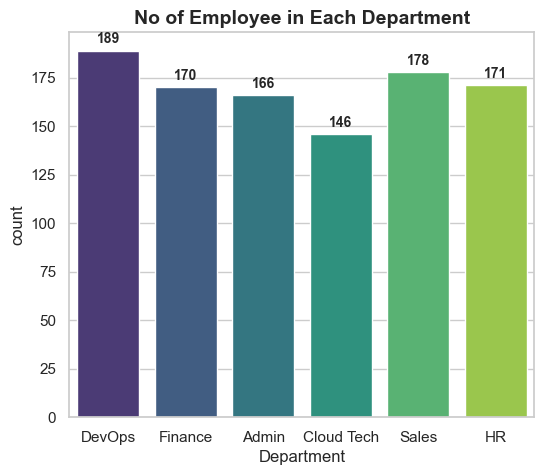

In [112]:
plt.figure(figsize=(6,5))
dept_chart=sns.countplot(x= 'Department' , data=df, palette='viridis')
# dept_chart.bar_label(dept_chart.containers[0])
for container in dept_chart.containers:
    dept_chart.bar_label(container, fontsize=10, fontweight='bold', padding=3)
plt.title("No of Employee in Each Department" , fontsize=14, fontweight='bold')
plt.show()


"Workforce Distribution & Operational Alignment:Organizational mapping reveals that DevOps serves as the largest structural unit with 189 active employees, while Cloud Tech remains the leanest operating unit at 146 employees. Cross-referencing this distribution with financial payroll metrics confirms a direct correlation between departmental headcount and aggregate expenditure. Budgetary scaling is volume-driven rather than wage-skewed, demonstrating a stable and standardized compensation architecture across all business units."

In [113]:
# dept_chart
# df.groupby('Department')['Salary'].sum()
df['Performance_Score'].unique().tolist()

['Average', 'Excellent', 'Good', 'Poor']

C:\Users\amank\AppData\Local\Temp\ipykernel_26424\1391029551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Salary', data=salary_dept , palette='viridis')


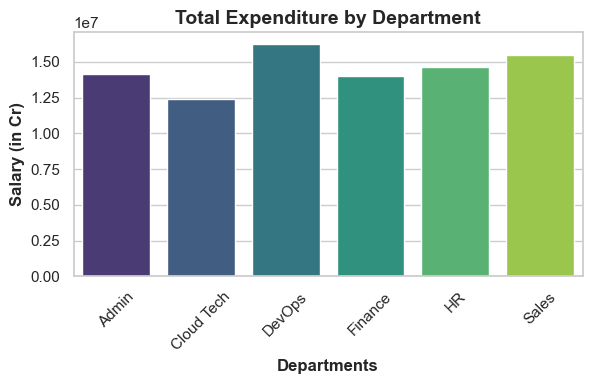

In [114]:
salary_dept=df.groupby('Department')['Salary'].sum().reset_index()
salary_dept
plt.figure(figsize=(6, 4))
sns.barplot(x='Department', y='Salary', data=salary_dept , palette='viridis')
plt.xticks(rotation=45)
plt.title('Total Expenditure by Department', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.xlabel('Departments' , fontweight='bold')
plt.ylabel('Salary (in Cr)' ,fontweight='bold')
plt.show()

"Departmental Financial Expenditure Analysis:Financial infrastructure tracking shows that DevOps represents the largest single payroll cost center, consuming over 1.62 Crores in total expenditure. This is closely followed by Sales at 1.55 Crores, reflecting heavy corporate investment in technical infrastructure and revenue-generating teams. Conversely, Cloud Tech remains the most lean department, operating at a total payroll footprint of approximately 1.24 Crores.

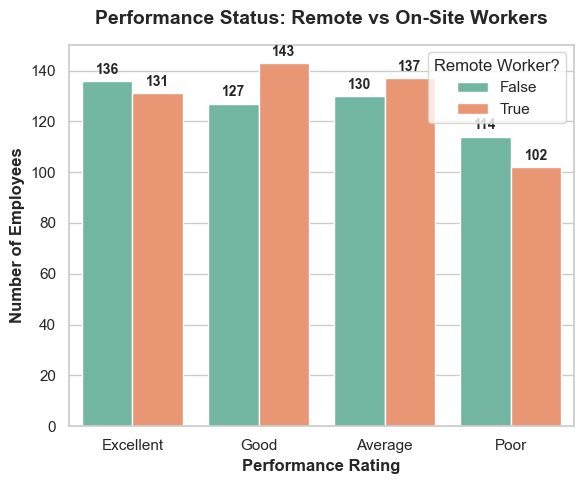

In [115]:
plt.figure(figsize=(6, 5))

# Define the correct order of performance from best to worst
score_order = ['Excellent', 'Good', 'Average', 'Poor']

# 1. Create a countplot to show the raw distribution of scores
# 'hue' breaks down each performance category by Remote Work status
ax = sns.countplot(
    x='Performance_Score', 
    hue='Remote_Work', 
    data=df, 
    order=score_order, 
    palette='Set2'
)

# 2. Add total headcount numbers on top of each colored bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', padding=3)

# 3. Add professional labels
plt.title('Performance Status: Remote vs On-Site Workers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Performance Rating', fontweight='bold', fontsize=12)
plt.ylabel('Number of Employees', fontweight='bold', fontsize=12)
plt.legend(title='Remote Worker?', loc='upper right')
plt.tight_layout()
plt.show()


"Workplace Flexibility & Productivity Analysis:Data distribution reveals that remote work adoption correlates with a stronger concentration of high-tier performance scores. Remote employees (True) outperform their on-site counterparts in both the 'Good' (143 vs. 127) and 'Average' (137 vs. 130) rating brackets.Crucially, remote arrangements do not compromise accountability, as evidenced by a 10.5% lower volume of 'Poor' ratings among remote workers (102 employees) compared to on-site workers (114 employees). This demonstrates that structured work-from-home policies in this organization successfully support productivity while mitigating poor operational output."

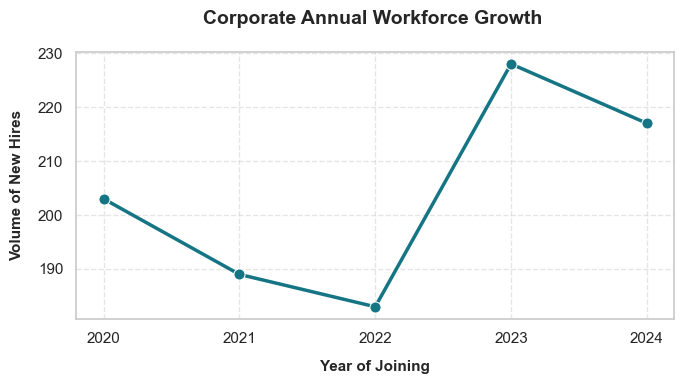

In [116]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'], errors='coerce')
df['Join_Year'] = df['Join_Date'].dt.year
hiring_trend = df['Join_Year'].value_counts().sort_index().reset_index()
hiring_trend.columns = ['Year', 'Employees_Hired']

# 4. Initialize a clean, premium chart canvas
plt.figure(figsize=(7, 4))
sns.set_theme(style="whitegrid")
sns.lineplot(
    x='Year', 
    y='Employees_Hired', 
    data=hiring_trend, 
    marker='o', 
    markersize=8,
    color="#157584", # Premium corporate dark blue
    linewidth=2.5
)
# 7. Apply high-tier professional formatting
plt.title('Corporate Annual Workforce Growth ', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Year of Joining', fontweight='bold', fontsize=11, labelpad=10)
plt.ylabel('Volume of New Hires', fontweight='bold', fontsize=11, labelpad=10)
plt.grid(axis='both', linestyle='--', alpha=0.5 )

# Force the X-axis to only show clean, non-decimal integer years
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

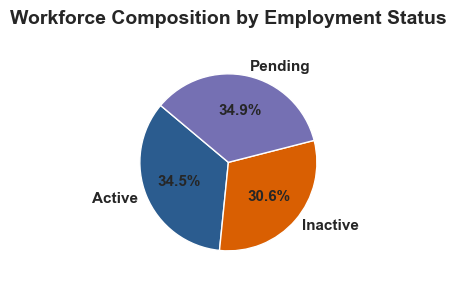

In [117]:
status_counts = df.groupby('Status').size()

plt.figure(figsize=(3, 4))

# 2. Plot the pie chart with matching slice labels and clean corporate colors
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',           # Formats numbers as clean percentages (e.g., 45.2%)
    startangle=140,              # Rotates chart for optimal text readability
    colors=['#2b5c8f', '#d95f02', '#7570b3'], # Premium professional palette
    textprops={'fontweight': 'bold', 'fontsize': 11}
)

plt.title('Workforce Composition by Employment Status', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

C:\Users\amank\AppData\Local\Temp\ipykernel_26424\1902690481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Region', y='Employee_Count', data=region_data, palette='viridis')


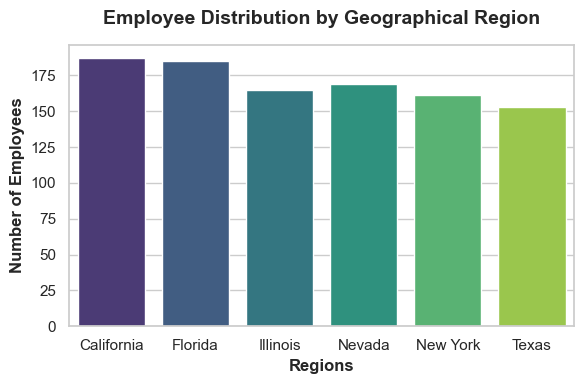

In [118]:
region_data = df.groupby('Region').size().reset_index(name='Employee_Count')

plt.figure(figsize=(6, 4))

# 2. Pass the clean table columns to x and y
ax = sns.barplot(x='Region', y='Employee_Count', data=region_data, palette='viridis')
plt.title('Employee Distribution by Geographical Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Regions', fontweight='bold')
plt.ylabel('Number of Employees', fontweight='bold')
plt.tight_layout()
plt.show()